# Option A Exploration

This notebook contains the exploration component for Option A, due the week after the main notebook. Choose something related to the topics covered in the main notebook and build something creative or interesting.

_For this notebook some helpful staring points for the extension include:_
* **Projection:** Use your calibrated intrinsics to render wireframe 3D shapes (cylinders, cubes, spheres, etc.) overlaid
  onto a real image with correct perspective.
* **Extrinsic calibration:** Given known object dimensions, compute the 3D pose (position + orientation) between an object
   and the camera, and verify by overlaying a wireframe.
* **Vanishing points in the wild:** Apply the calibration techniques from this notebook to your own photos — estimate
  focal lengths, or use vanishing points to measure real-world distances from a single photograph.

For more detailed instructions, please see the [Project 2 Guidelines](https://docs.google.com/document/d/1_w5RefFChBW3IdvhiCvtLgPGkIDNeWNKhVrLjKPL2Fw/edit?usp=sharing)


## Review of current methods (10 points)
Once you’ve selected a topic or project idea, explore the literature space. Has there been academic research on this topic? Are there tutorials online, software packages, or libraries?

Select at least 5 resources (youtube videos, papers, tutorials, opensource software, libraries, etc) and provide a short description (2-3 sentences) below:

* Source 1: https://www.youtube.com/watch?v=2HfIU5lp-0I In the video, titled “Find The Horizon Line & Vanishing Points On ANY Image” Dan, explains what the horizon line and the vanishing points are when drawing a portray and how they should be used for a portrayal to be accurate. This provides a more clear intuition on this concepts.
* Source 2: https://www.youtube.com/watch?v=ffvojZONF_A Ihe video, titled “The Cross Ratio”, professor Federico Ardila from San Francisco State University, takes us through the steps to compute the distance between goal and play based on the picture of a soccer game using the cross ratio. It brings clarity to the steps of the process.
* Source 3: https://www.mathworks.com/help/vision/ug/camera-calibration.html This article from the MATLAB help center, talks about camera calibration, particularly given extrinsic parameters which will be useful for this project.
* Source 4: https://www.youtube.com/watch?v=atPLxuaU9-g In the context of single-view metrology, the lecture in the video provides a formula for determining the height based on reference points and the vanishing lines.
* Source 5: https://visionbook.mit.edu/3d_scene_understanding_single_view.html The article from MIT, provides a series of more simplified formulas to identify elements such as the horizon line, focus point and provides picture examples for all of this.

## Code (70 points)
We expect you to write code for this project (CS131 is, after all, a CS class 🙂). You may implement algorithms from scratch or expand on algorithms from this notebook if you would like, but using other libraries or other open-source software in a creative way is also sufficient.

You not required to develop your code in this notebook! Feel free to create your own jupyter notebook for the project or write code in your environment of choice! (Jupyter notebook or google colab are good starting options)!


In [ ]:
# Please add your code here
# If you do not write your code in this notebook, please attach a link to any code that you wrote!


In [5]:

import os

# Clone the repository if it's not already cloned
repo_path = 'CS131_release'
if not os.path.exists(repo_path):
    !git clone https://github.com/MauricioAlvarez-21/CS131_release.git

# Navigate to the correct directory where filtersA.py is expected to be
# You might need to adjust this path based on where filtersA.py actually resides within the cloned repo.
# For example, if it's directly in 'spring_2026/project2_release/option_A/', you'd set that path.
project_path = os.path.join(repo_path, 'spring_2026', 'project2_release', 'option_A')
if os.path.exists(project_path):
    os.chdir(project_path)
    print(f"Changed current directory to: {os.getcwd()}")
else:
    print(f"Project path not found: {project_path}. Please verify the path within the cloned repository.")

Cloning into 'CS131_release'...
remote: Enumerating objects: 2968, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 2968 (delta 16), reused 2 (delta 2), pack-reused 2949 (from 2)
Receiving objects: 100% (2968/2968), 196.20 MiB | 18.80 MiB/s, done.
Resolving deltas: 100% (1025/1025), done.
Changed current directory to: /content/CS131_release/spring_2026/project2_release/option_A/CS131_release/spring_2026/project2_release/option_A


Image is 1300 x 975


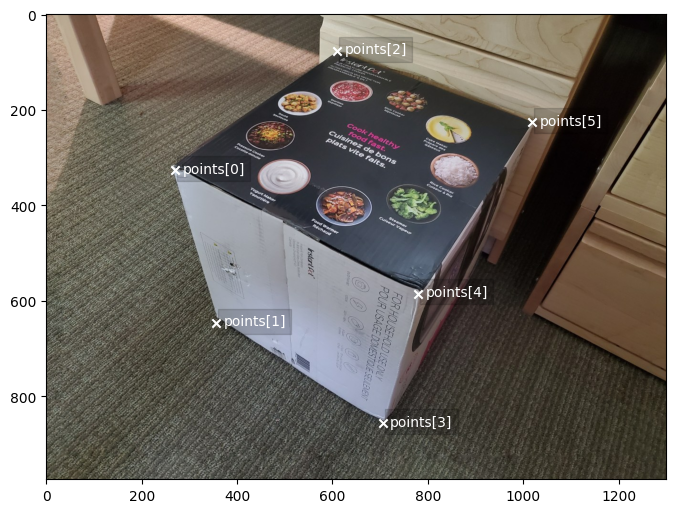

In [4]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from typing import Tuple
# Load image and annotated points; note that:
# > Our image is a PIL image type; you can convert this to NumPy with `np.asarray(img)`
# > Points are in (x, y) format, which corresponds to (col, row)!
img = Image.open("images/pressure_cooker.jpg")
print(f"Image is {img.width} x {img.height}")
points = np.array(
    [
        [270.0, 327.0],  # [0]
        [356.0, 647.0],  # [1]
        [610.0, 76.0],  # [2]
        [706.0, 857.0],  # [3]
        [780.0, 585.0],  # [4]
        [1019.0, 226.0],  # [5]
    ]
)

# Visualize image & annotated points
fig, ax = plt.subplots(figsize=(8, 10))
ax.imshow(img)
ax.scatter(points[:, 0], points[:, 1], color="white", marker="x")
for i in range(len(points)):
    ax.annotate(
        f"points[{i}]",
        points[i] + np.array([15.0, 5.0]),
        color="white",
        backgroundcolor=(0, 0, 0, 0.15),
        zorder=0.1,
    )

## Writeup (20 points)

An explanation of what you did, and how it relates to the topic of choice. (~200 words) Please attach any images, figures, etc.

_You may also add a link to your writeup if that is easier!_